# Customer Segmentation Analysis using Python

## Project Overview
Customer segmentation is the process of dividing customers into
groups based on their purchasing behavior.

This project uses transaction data to identify customer groups
based on how recently they purchased, how frequently they purchase,
and how much they spend.

## Objectives
1. Clean and prepare transaction data.
2. Analyze sales and customer behavior.
3. Calculate Recency, Frequency, and Monetary values.
4. Segment customers using RFM analysis.
5. Apply K-Means clustering.
6. Visualize customer segments.
7. Generate business insights and recommendations.

Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


Load your Excel file

In [4]:
df = pd.read_excel("Online Retail.xlsx", sheet_name="Online Retail")

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

display(df.head())

Dataset loaded successfully!
Rows and columns: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Inspect the raw dataset

In [5]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe(include="all").T)

Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice 

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Clean The Data

In [6]:
raw_df = df.copy()

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Remove rows without a customer ID
df = df.dropna(subset=["CustomerID"]).copy()

# Convert columns to their correct data types
df["CustomerID"] = pd.to_numeric(
    df["CustomerID"], errors="coerce"
)

df["Quantity"] = pd.to_numeric(
    df["Quantity"], errors="coerce"
)

df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"], errors="coerce"
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"], errors="coerce"
)

# Remove rows with invalid required fields
df = df.dropna(
    subset=["CustomerID", "Quantity", "UnitPrice", "InvoiceDate"]
).copy()

df["CustomerID"] = df["CustomerID"].astype(int)

# Exclude cancelled invoices
df["InvoiceNo"] = df["InvoiceNo"].astype(str).str.strip()

df = df[
    ~df["InvoiceNo"].str.startswith("C", na=False)
].copy()

# Keep positive-quantity, positive-price sales
df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

print("Cleaning completed!")
print("Cleaned shape:", df.shape)

Cleaning completed!
Cleaned shape: (392692, 8)


Create The Sales Formula

TotalSales=Quantity×UnitPrice

In [8]:
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

display(
    df[[
        "InvoiceNo",
        "CustomerID",
        "Quantity",
        "UnitPrice",
        "TotalSales"
    ]].head(10)
)

,InvoiceNo,CustomerID,Quantity,UnitPrice,TotalSales
0,536365,17850,6,2.55,15.30
1,536365,17850,6,3.39,20.34
2,536365,17850,8,2.75,22.00
3,536365,17850,6,3.39,20.34
4,536365,17850,6,3.39,20.34
5,536365,17850,2,7.65,15.30
6,536365,17850,6,4.25,25.50
7,536366,17850,6,1.85,11.10
8,536366,17850,6,1.85,11.10
9,536367,13047,32,1.69,54.08


Calculate Overall Business Metrics

In [9]:
total_customers = df["CustomerID"].nunique()
total_orders = df["InvoiceNo"].nunique()
total_products = df["StockCode"].nunique()
total_quantity = df["Quantity"].sum()
total_revenue = df["TotalSales"].sum()

print("Total Customers:", total_customers)
print("Total Orders:", total_orders)
print("Total Products:", total_products)
print("Total Quantity Sold:", total_quantity)
print("Total Revenue:", round(total_revenue, 2))

Total Customers: 4338
Total Orders: 18532
Total Products: 3665
Total Quantity Sold: 5152002
Total Revenue: 8887208.89


Calculate Customer Level Summary

In [10]:
customer_summary = df.groupby("CustomerID").agg(
    Total_Sales=("TotalSales", "sum"),
    Total_Orders=("InvoiceNo", "nunique"),
    Total_Quantity=("Quantity", "sum"),
    Last_Purchase=("InvoiceDate", "max"),
    Country=("Country", "last")
).reset_index()

display(customer_summary.head(10))

,CustomerID,Total_Sales,Total_Orders,Total_Quantity,Last_Purchase,Country
0,12346,77183.60,1,74215,2011-01-18 10:01:00,United Kingdom
1,12347,4310.00,7,2458,2011-12-07 15:52:00,Iceland
2,12348,1797.24,4,2341,2011-09-25 13:13:00,Finland
3,12349,1757.55,1,631,2011-11-21 09:51:00,Italy
4,12350,334.40,1,197,2011-02-02 16:01:00,Norway
5,12352,2506.04,8,536,2011-11-03 14:37:00,Norway
6,12353,89.00,1,20,2011-05-19 17:47:00,Bahrain
7,12354,1079.40,1,530,2011-04-21 13:11:00,Spain
8,12355,459.40,1,240,2011-05-09 13:49:00,Bahrain
9,12356,2811.43,3,1591,2011-11-17 08:40:00,Portugal


Calculate RFM Values

R=Reference Date−Last Purchase Date
F=Number of Distinct Invoices
M=∑(Quantity×UnitPrice)

In [11]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate",
             lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalSales", "sum")
).reset_index()

display(rfm.head(10))

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


RFM Descripitive Statistics

In [12]:
display(
    rfm[["Recency", "Frequency", "Monetary"]].describe().round(2)
)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


Visualize RFM Distributions

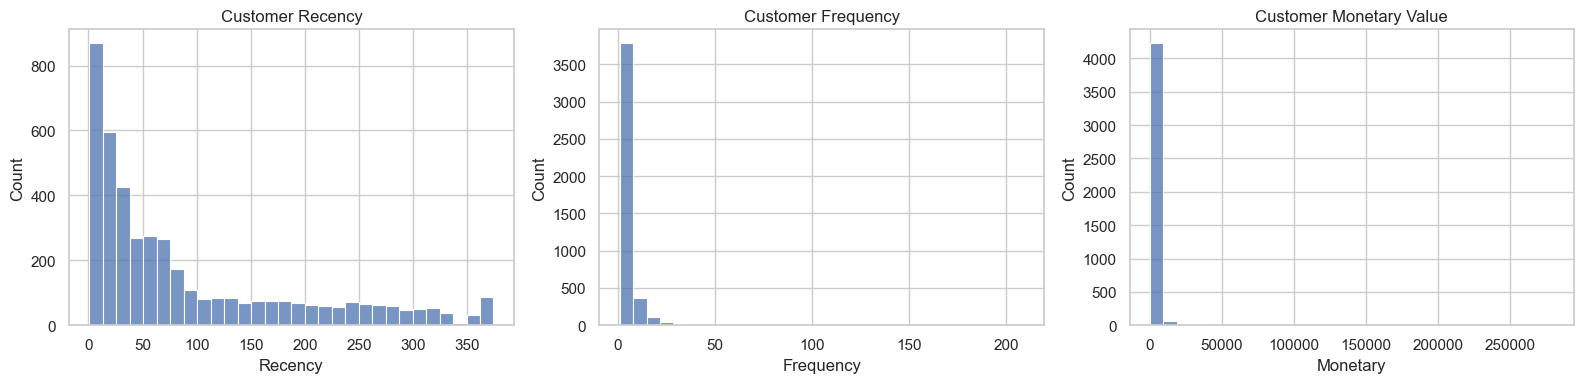

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=rfm, x="Recency", bins=30, ax=axes[0])
axes[0].set_title("Customer Recency")

sns.histplot(data=rfm, x="Frequency", bins=30, ax=axes[1])
axes[1].set_title("Customer Frequency")

sns.histplot(data=rfm, x="Monetary", bins=30, ax=axes[2])
axes[2].set_title("Customer Monetary Value")

plt.tight_layout()
plt.show()

Calculates RFM Scores

In [14]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

display(rfm.head(10))

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112
5,12352,36,8,2506.04,3,5,5,355
6,12353,204,1,89.00,1,1,1,111
7,12354,232,1,1079.40,1,1,4,114
8,12355,214,1,459.40,1,1,2,112
9,12356,23,3,2811.43,4,3,5,435


Assign Customer Segements

In [15]:
def assign_segment(row):
    if (
        row["R_Score"] >= 4
        and row["F_Score"] >= 4
        and row["M_Score"] >= 4
    ):
        return "Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 4:
        return "Loyal Customers"

    elif row["R_Score"] >= 4 and row["F_Score"] <= 2:
        return "Recent Customers"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Hibernating"

    else:
        return "Potential Loyalists"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

display(rfm.head(10))

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,5,115,Hibernating
1,12347,2,7,4310.00,5,5,5,555,Champions
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,Recent Customers
4,12350,310,1,334.40,1,1,2,112,Hibernating
5,12352,36,8,2506.04,3,5,5,355,Loyal Customers
6,12353,204,1,89.00,1,1,1,111,Hibernating
7,12354,232,1,1079.40,1,1,4,114,Hibernating
8,12355,214,1,459.40,1,1,2,112,Hibernating
9,12356,23,3,2811.43,4,3,5,435,Potential Loyalists


Count Customers In Each Segement

In [16]:
segment_counts = rfm["Segment"].value_counts()

display(segment_counts)

Segment
Hibernating            1074
Champions               942
Potential Loyalists     843
At Risk                 661
Loyal Customers         508
Recent Customers        310
Name: count, dtype: int64

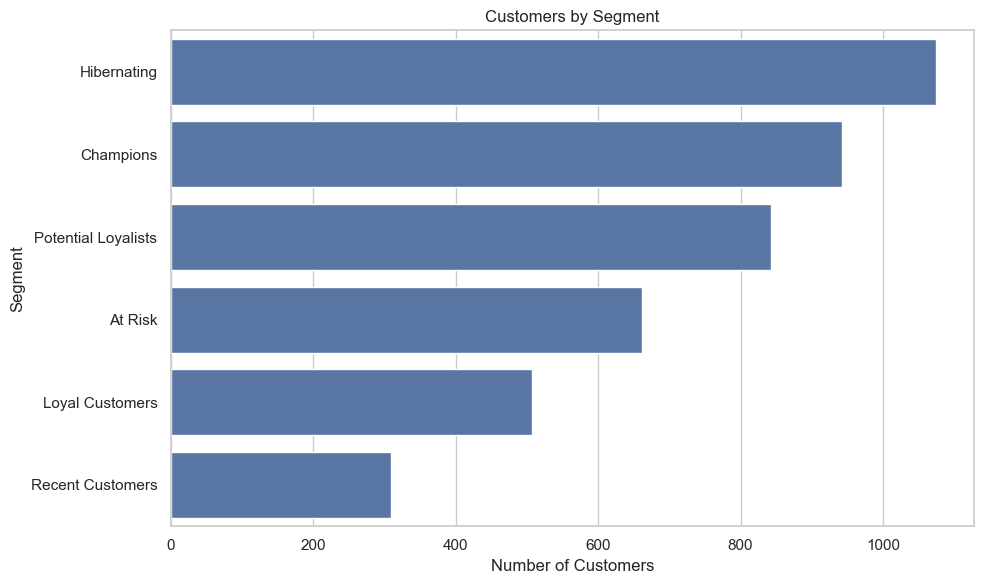

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title("Customers by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

Calaulate Revenue By Segement

In [18]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "nunique"),
    Average_Recency=("Recency", "mean"),
    Average_Frequency=("Frequency", "mean"),
    Average_Spending=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).round(2)

segment_summary["Customer_Percentage"] = (
    segment_summary["Customers"] / len(rfm) * 100
).round(2)

segment_summary["Revenue_Percentage"] = (
    segment_summary["Total_Revenue"] /
    segment_summary["Total_Revenue"].sum() * 100
).round(2)

display(
    segment_summary.sort_values(
        "Total_Revenue",
        ascending=False
    )
)

,Customers,Average_Recency,Average_Frequency,Average_Spending,Total_Revenue,Customer_Percentage,Revenue_Percentage
Segment,,,,,,,
Champions,942,12.50,11.20,6091.24,5737952.12,21.72,64.56
Loyal Customers,508,37.21,5.12,1826.03,927623.75,11.71,10.44
At Risk,661,150.64,3.41,1246.46,823912.44,15.24,9.27
Potential Loyalists,843,38.97,1.85,867.95,731677.86,19.43,8.23
Hibernating,1074,216.68,1.10,487.71,523803.28,24.76,5.89
Recent Customers,310,18.10,1.25,458.84,142239.44,7.15,1.60


Create A Revenue Chart

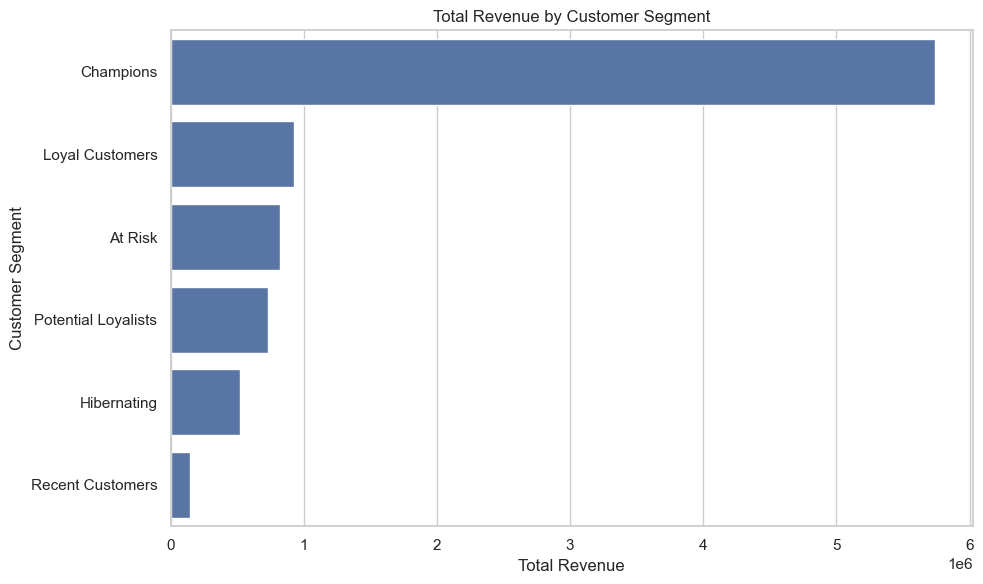

In [19]:
revenue_by_segment = (
    segment_summary["Total_Revenue"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=revenue_by_segment.values,
    y=revenue_by_segment.index
)

plt.title("Total Revenue by Customer Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

Apply K- Means Culstering

In [20]:
features = ["Recency", "Frequency", "Monetary"]

X = rfm[features].copy()

X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Clustering data prepared!")

Clustering data prepared!


Use the elbow method

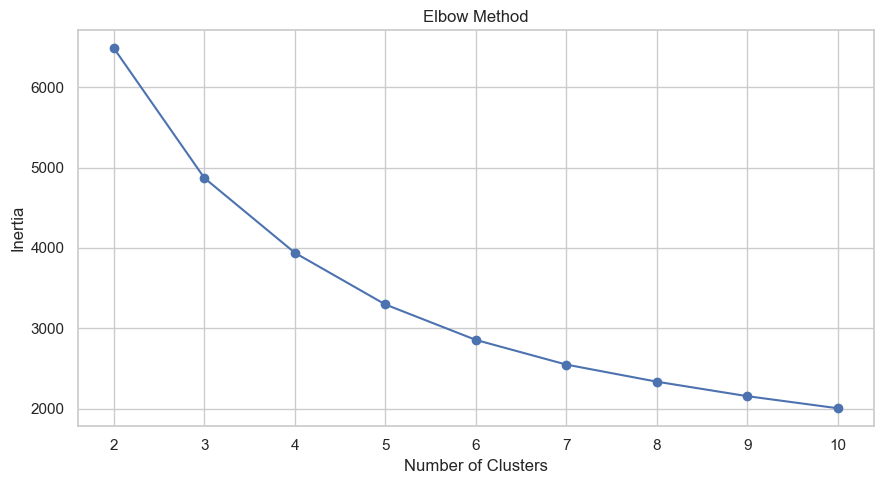

In [21]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertias, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

Train The Model

In [22]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print(rfm["Cluster"].value_counts().sort_index())

Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


Evaluate Culstering

In [23]:
score = silhouette_score(X_scaled, rfm["Cluster"])

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.338


Summarize Culster

In [24]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "nunique"),
    Average_Recency=("Recency", "mean"),
    Average_Frequency=("Frequency", "mean"),
    Average_Spending=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).round(2)

display(cluster_summary)

,Customers,Average_Recency,Average_Frequency,Average_Spending,Total_Revenue
Cluster,,,,,
0,713,12.17,13.75,8088.02,5766757.07
1,1622,181.51,1.32,341.00,553099.77
2,837,17.70,2.19,557.32,466479.03
3,1166,71.64,4.08,1801.78,2100873.02


Plot Culsters

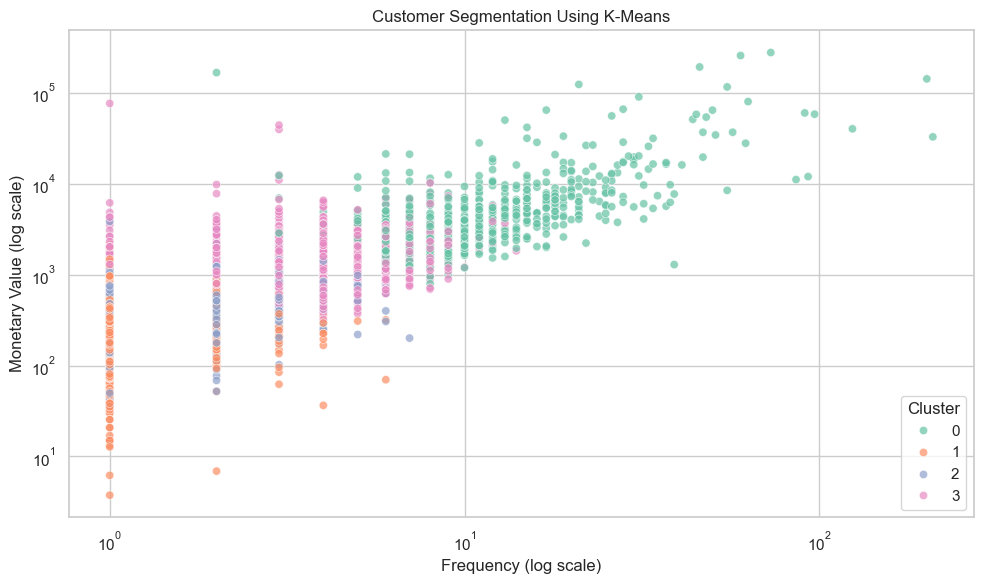

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.title("Customer Segmentation Using K-Means")
plt.xlabel("Frequency (log scale)")
plt.ylabel("Monetary Value (log scale)")
plt.tight_layout()
plt.show()

RFM HeatMap

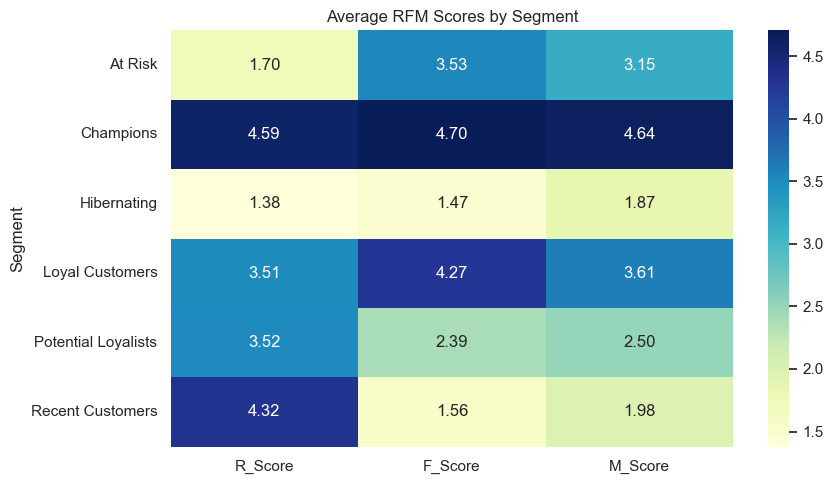

In [26]:
rfm_heatmap = rfm.groupby("Segment")[
    ["R_Score", "F_Score", "M_Score"]
].mean()

plt.figure(figsize=(9, 5))

sns.heatmap(
    rfm_heatmap,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average RFM Scores by Segment")
plt.tight_layout()
plt.show()

Generate key business insights

In [27]:
print("CUSTOMER SEGMENTATION INSIGHTS")
print("-" * 40)

print("Total Customers:", rfm["CustomerID"].nunique())

print(
    "Largest Customer Segment:",
    segment_summary["Customers"].idxmax()
)

print(
    "Highest Revenue Segment:",
    segment_summary["Total_Revenue"].idxmax()
)

print(
    "Highest Average Spending Segment:",
    segment_summary["Average_Spending"].idxmax()
)

print(
    "Most Recent Segment on Average:",
    segment_summary["Average_Recency"].idxmin()
)

display(segment_summary)

CUSTOMER SEGMENTATION INSIGHTS
----------------------------------------
Total Customers: 4338
Largest Customer Segment: Hibernating
Highest Revenue Segment: Champions
Highest Average Spending Segment: Champions
Most Recent Segment on Average: Champions


,Customers,Average_Recency,Average_Frequency,Average_Spending,Total_Revenue,Customer_Percentage,Revenue_Percentage
Segment,,,,,,,
At Risk,661,150.64,3.41,1246.46,823912.44,15.24,9.27
Champions,942,12.50,11.20,6091.24,5737952.12,21.72,64.56
Hibernating,1074,216.68,1.10,487.71,523803.28,24.76,5.89
Loyal Customers,508,37.21,5.12,1826.03,927623.75,11.71,10.44
Potential Loyalists,843,38.97,1.85,867.95,731677.86,19.43,8.23
Recent Customers,310,18.10,1.25,458.84,142239.44,7.15,1.60


Export your final results

In [28]:
# Customer-level RFM scores and segments
rfm.to_csv("customer_segments.csv", index=False)

rfm.to_excel("customer_segments.xlsx", index=False)

# Summary tables
segment_summary.to_csv("segment_summary.csv")
cluster_summary.to_csv("cluster_summary.csv")

print("All output files saved successfully!")

All output files saved successfully!


Final Validation

In [29]:
print("FINAL VALIDATION")
print("-" * 40)

print("Clean transaction rows:", len(df))
print("Unique customers:", df["CustomerID"].nunique())
print("RFM rows:", len(rfm))
print("Missing values in RFM:", rfm.isnull().sum().sum())
print("Duplicate customer IDs in RFM:", rfm["CustomerID"].duplicated().sum())

display(rfm.head())

FINAL VALIDATION
----------------------------------------
Clean transaction rows: 392692
Unique customers: 4338
RFM rows: 4338
Missing values in RFM: 0
Duplicate customer IDs in RFM: 0


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
0,12346,326,1,77183.60,1,1,5,115,Hibernating,3
1,12347,2,7,4310.00,5,5,5,555,Champions,0
2,12348,75,4,1797.24,2,4,4,244,At Risk,3
3,12349,19,1,1757.55,4,1,4,414,Recent Customers,2
4,12350,310,1,334.40,1,1,2,112,Hibernating,1
